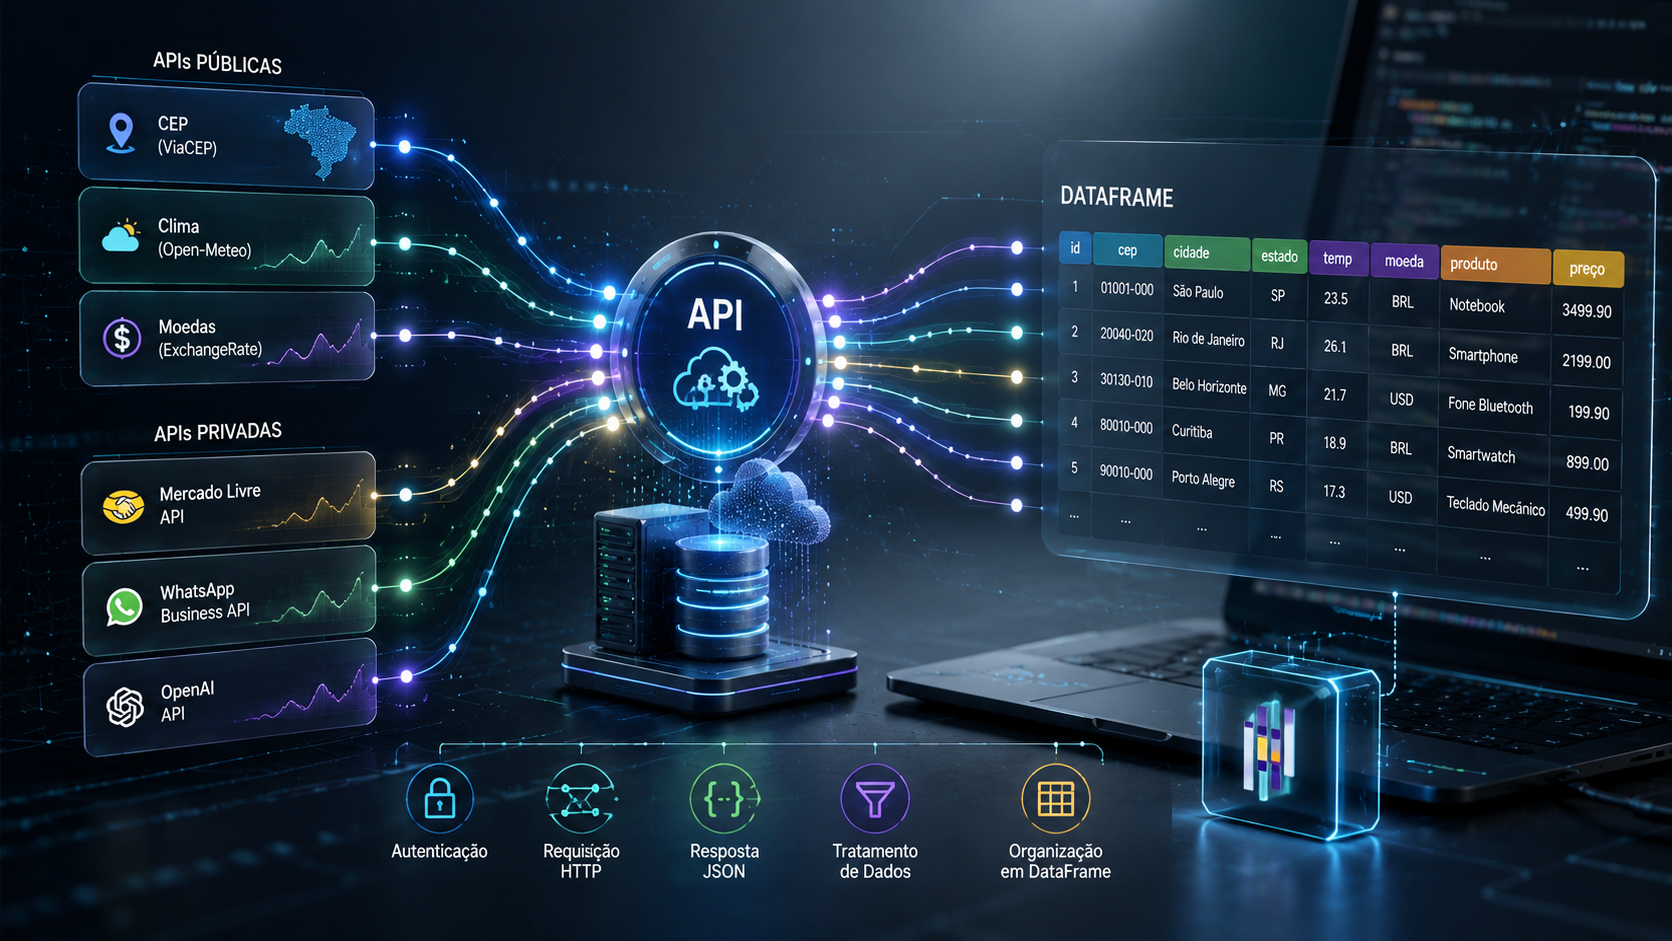

## Consumo de APIs: Obtenção de dados externos e organização em DataFrames

Nesta aula, estudaremos como aplicações em Python podem obter dados de serviços externos por meio de **APIs (Application Programming Interfaces)** e transformar as respostas recebidas em estruturas tabulares com `pandas`.

O foco da aula é o fluxo:

$$
\colorbox{#F1F5F9}{\text{documentação}}\;\longrightarrow\;
\colorbox{#E2E8F0}{\text{requisição HTTP}}\;\longrightarrow\;
\colorbox{#CBD5E1}{\text{resposta}}\;\longrightarrow\;
\colorbox{#B6C3D1}{\text{JSON}}\;\longrightarrow\;
\colorbox{#94A3B8}{\text{seleção de campos}}\;\longrightarrow\;
\colorbox{#718096}{\text{DataFrame}}\;\longrightarrow\;
\colorbox{#526477}{\color{white}{\text{validação}}}
$$

Serão utilizados seis exemplos:

| Tipo de acesso | API | Aplicação |
|---|---|---|
| Sem autenticação | ViaCEP | Consulta de endereços por CEP |
| Sem autenticação | IBGE | Consulta de estados e municípios |
| Sem autenticação | Open-Meteo | Dados meteorológicos |
| Com autenticação | Mercado Livre | OAuth 2.0 e recursos da conta |
| Com autenticação | GitHub | Token de acesso e dados do usuário |
| Com autenticação | OpenWeather | API Key e dados meteorológicos |

**Objetivo principal:** obter dados externos por meio de APIs e organizá-los em `DataFrame` para posterior análise, armazenamento ou integração com outros sistemas.

**Objetivos específicos**


1. explicar o que é uma API e identificar seus principais componentes;
2. interpretar a documentação de uma API REST;
3. diferenciar endpoint, método HTTP, parâmetro, header, payload e resposta;
4. realizar requisições HTTP em Python com a biblioteca `requests`;
5. verificar códigos de status e tratar erros básicos;
6. interpretar respostas em JSON;
7. transformar estruturas JSON em `DataFrame`;
8. consumir APIs sem autenticação;
9. utilizar credenciais em APIs que exigem autenticação;
10. compreender o fluxo OAuth 2.0 utilizado pelo Mercado Livre;
11. evitar a exposição de tokens, chaves e segredos no notebook.

# 1. O que é uma API?

Uma **API**, ou *Application Programming Interface*, define uma interface pela qual dois sistemas de software podem trocar dados ou solicitar operações.

Em uma aplicação web tradicional, uma pessoa utiliza uma interface gráfica. No consumo de uma API, um programa envia uma **requisição** diretamente a outro sistema.

Podemos representar o processo de forma simplificada:


$$\colorbox{#DCEEFF}{\text{Cliente}}\;\longrightarrow\;\colorbox{#FFF0CC}{\text{Requisição HTTP}}\;\longrightarrow\;\colorbox{#DDF4E4}{\text{API}}$$

$$\colorbox{#DCEEFF}{\text{Cliente}}\;\longleftarrow\;\colorbox{#EADFFF}{\text{Resposta HTTP}}\;\longleftarrow\;\colorbox{#DDF4E4}{\text{API}}$$

Nesta aula, o cliente será um programa Python executado no Jupyter Notebook.

## 2 Tipos de APIs

As APIs podem ser classificadas de diferentes formas, dependendo de sua arquitetura, protocolo de comunicação e finalidade. Entre os principais tipos encontrados em sistemas computacionais estão **SOAP, RPC, GraphQL e REST**.

### SOAP

**SOAP (*Simple Object Access Protocol*)** é um protocolo de comunicação baseado em mensagens estruturadas, normalmente utilizando **XML**.

Possui regras mais rígidas para a definição e troca de mensagens, sendo comum em sistemas corporativos que exigem contratos bem definidos, padronização e mecanismos formais de segurança.

**Aplicação:** integração entre sistemas bancários, sistemas governamentais e plataformas empresariais.

$$
\colorbox{#F3DDE3}{\text{Sistema A}}\;\longrightarrow\;\colorbox{#DDE5ED}{\text{mensagem XML}}\;
\longrightarrow\;\colorbox{#E8DFC9}{\text{serviço SOAP}}\;\longrightarrow\;
\colorbox{#DDE5ED}{\text{mensagem XML}}\;\longrightarrow\;
\colorbox{#F3DDE3}{\text{Sistema A}}
$$

### RPC

**RPC (*Remote Procedure Call*)**, ou **Chamada de Procedimento Remoto**, é um modelo de comunicação no qual um sistema **cliente solicita a execução de uma função ou procedimento localizado em um servidor remoto**.

A ideia central da RPC é permitir que uma operação executada em outro sistema seja solicitada de maneira semelhante a uma chamada de função.

Por exemplo, suponha que um servidor disponibilize uma função responsável pelo cálculo do valor de um frete:

```python
def calcular_frete(cep, peso):
    # processamento realizado no servidor
    return valor_frete
```

O cliente pode solicitar a execução dessa operação informando os parâmetros necessários:

```text
calcularFrete("01001000", 2.5)
```

Nesse processo, **a função não é executada no cliente**. O cliente apenas informa ao servidor qual operação deseja executar e quais valores devem ser utilizados como parâmetros.

O fluxo pode ser representado por:

$$
\colorbox{#E6E0F0}{\text{Cliente}}
\;\xrightarrow{\text{função + parâmetros}}\;
\colorbox{#DDEBE3}{\text{Servidor}}
\;\xrightarrow{\text{executa a função}}\;
\colorbox{#F2E3CF}{\text{Resultado}}
\;\longrightarrow\;
\colorbox{#E6E0F0}{\text{Cliente}}
$$

**Aplicação:** RPC é utilizada na comunicação entre sistemas distribuídos e **microsserviços**, especialmente quando diferentes componentes de uma aplicação precisam solicitar operações uns aos outros. Uma tecnologia amplamente utilizada nesse contexto é o **gRPC**, que implementa o paradigma RPC para comunicação entre aplicações.


### GraphQL

**GraphQL** é uma linguagem de consulta para APIs e um ambiente de execução que permite ao **cliente especificar exatamente quais dados deseja receber do servidor**.

Uma das principais características do GraphQL é permitir que diferentes informações relacionadas sejam solicitadas em uma única consulta, selecionando apenas os campos necessários.

Considere, por exemplo, um sistema que armazena informações sobre usuários. Um usuário pode possuir diversos atributos, como:

```text
id
nome
email
telefone
data_nascimento
endereco
pedidos
```

Se uma aplicação precisar apenas do nome e do e-mail de um usuário, poderá realizar uma consulta GraphQL como:

```graphql
query {
    usuario(id: 123) {
        nome
        email
    }
}
```

O servidor processa a consulta e retorna somente os campos solicitados:

```json
{
    "data": {
        "usuario": {
            "nome": "Ana Silva",
            "email": "ana@email.com"
        }
    }
}
```

Portanto, no GraphQL, **o cliente possui maior controle sobre a estrutura dos dados retornados**.

Isso é particularmente útil quando os dados possuem relacionamentos. Por exemplo, podemos solicitar informações do usuário e de seus pedidos na mesma consulta:

```graphql
query {
    usuario(id: 123) {
        nome
        email
        pedidos {
            id
            valor
            data
        }
    }
}
```


**Aplicação:** GraphQL é utilizado em aplicações web e móveis que trabalham com dados relacionados e podem precisar de diferentes conjuntos de atributos em diferentes telas. Uma interface de perfil, por exemplo, pode solicitar apenas `nome` e `foto`, enquanto outra tela pode solicitar `nome`, `email`, `pedidos` e outras informações relacionadas.

Apesar dessa flexibilidade, **REST continua sendo uma das abordagens mais difundidas para construção e consumo de APIs Web**. Como as APIs utilizadas nos exemplos desta aula são predominantemente baseadas em requisições HTTP no estilo REST, aprofundaremos a seguir a organização de **recursos e endpoints em APIs REST**.


### REST

**REST (*Representational State Transfer*)** é um estilo arquitetural amplamente utilizado na construção de APIs Web.

Em uma API REST, os dados são normalmente organizados como **recursos**, identificados por URLs. As operações sobre esses recursos são realizadas utilizando os métodos do protocolo HTTP, como `GET`, `POST`, `PUT`, `PATCH` e `DELETE`.

Por exemplo, considere uma API que disponibiliza informações sobre clientes:

```text
https://api.exemplo.com/clientes
```

O recurso representado nesse endereço é:

```text
clientes
```

Uma consulta a um cliente específico poderia utilizar:

```text
GET https://api.exemplo.com/clientes/123  Clientes é o recurso específico do site
```

Nesse caso:

* `GET` indica a operação de consulta;
* `clientes` representa o recurso;
* `123` identifica o cliente solicitado. # Id de um cliente específico

As APIs REST são particularmente relevantes para esta aula porque grande parte das APIs disponíveis na Web utiliza HTTP para disponibilizar dados, frequentemente retornados no formato **JSON**.

Os exemplos que utilizaremos, como **ViaCEP, IBGE, Open-Meteo, Mercado Livre, GitHub e OpenWeather**, seguem esse tipo de interação baseada em requisições HTTP.

Antes de começarmos a consumir essas APIs em Python, precisamos compreender melhor como uma API REST organiza seus **recursos e endpoints**. Esse será o assunto da próxima seção.


## 2.1 API REST e recursos

Muitas APIs disponíveis na Web seguem princípios associados à arquitetura REST. Nessas APIs, os dados são organizados em **recursos**, acessados por URLs denominadas **endpoints**.

Exemplo conceitual:

```text
https://api.exemplo.com/clientes/123
```

Podemos separar esse endereço em:

- **base URL:** `https://api.exemplo.com`
- **recurso:** `/clientes`
- **identificador:** `/123`

A URL completa utilizada para acessar uma operação específica é denominada **endpoint**.

## 2.2 Métodos HTTP

O método HTTP informa a operação que desejamos realizar.

| Método | Uso frequente |
|---|---|
| `GET` | consultar dados |
| `POST` | criar dados ou enviar informações para processamento |
| `PUT` | substituir um recurso |
| `PATCH` | atualizar parcialmente um recurso |
| `DELETE` | remover um recurso |

O objetivo principal desta aula é **obter dados externos**. Por isso, a maior parte das requisições utilizará `GET`.

## 2.3 Parâmetros, headers e body

Uma requisição HTTP pode transportar informações de diferentes maneiras. A posição de cada informação depende da finalidade do dado e das regras definidas pela API.

Considere uma API fictícia de uma loja virtual disponível em:

```text
https://api.loja.com
```

A partir desse exemplo, podemos identificar os principais componentes de uma requisição.

### Parâmetros de rota

Os **parâmetros de rota** fazem parte do próprio endpoint e normalmente são utilizados para identificar um recurso específico.

Por exemplo:

```text
GET https://api.loja.com/usuarios/123
```

Nesse caso:

* `/usuarios` representa o recurso que queremos consultar;
* `123` é um parâmetro de rota que identifica um usuário específico.

Assim, diferentes valores permitem acessar diferentes recursos:

```text
GET https://api.loja.com/usuarios/123
GET https://api.loja.com/usuarios/456
```

### Query parameters

Os **query parameters**, ou parâmetros de consulta, são utilizados para enviar informações adicionais ao servidor, frequentemente relacionadas a filtros, ordenação, paginação ou configuração da resposta.

Eles aparecem após o caractere `?` na URL:

```text
GET https://api.loja.com/produtos?categoria=notebooks&limite=10
```

Nesse exemplo, temos dois parâmetros:

```text
categoria = notebooks
limite = 10
```

O caractere `&` separa os diferentes parâmetros.

A requisição pode ser interpretada como:

> Consulte os produtos da categoria `notebooks` e retorne no máximo `10` registros.

Em Python, utilizando `requests`, não precisamos construir manualmente a query string. Podemos utilizar um dicionário:

```python
parametros = {
    "categoria": "notebooks",
    "limite": 10
}

resposta = requests.get(
    "https://api.loja.com/produtos",
    params=parametros
)
```

A biblioteca constrói a URL correspondente automaticamente.

### Headers

Os **headers** transportam metadados associados à requisição.

Eles não fazem parte diretamente dos dados que estamos consultando ou enviando. Em vez disso, fornecem informações adicionais sobre a comunicação entre cliente e servidor.

Um uso frequente é o envio de credenciais de autenticação:

```text
Authorization: Bearer TOKEN
```

Por exemplo:

```python
headers = {
    "Authorization": "Bearer TOKEN"
}

resposta = requests.get(
    "https://api.loja.com/usuarios/123",
    headers=headers
)
```

Nesse caso, o token permite que o servidor identifique ou autorize o cliente antes de fornecer o recurso solicitado.

Headers também podem informar o formato dos dados enviados ou esperados, como:

```text
Content-Type: application/json
Accept: application/json
```

### Body

O **body** corresponde ao corpo da requisição e permite enviar dados ao servidor.

É particularmente comum em operações como `POST`, `PUT` e `PATCH`.

Considere, por exemplo, o cadastro de um novo usuário:

```text
POST https://api.loja.com/usuarios
```

Os dados do usuário poderiam ser enviados no body em formato JSON:

```json
{
    "nome": "Ana Silva",
    "email": "ana@email.com",
    "cidade": "São Paulo"
}
```

Em Python:

```python
novo_usuario = {
    "nome": "Ana Silva",
    "email": "ana@email.com",
    "cidade": "São Paulo"
}

resposta = requests.post(
    "https://api.loja.com/usuarios",
    json=novo_usuario
)
```

Nesse caso, os dados contidos em `novo_usuario` são enviados no **body da requisição**.


A **documentação da API** determina quais métodos, parâmetros, headers e dados no body são aceitos ou obrigatórios em cada endpoint.


## 2.4 Códigos de status HTTP

Toda resposta HTTP possui um código de status.

| Faixa | Interpretação geral | Exemplos |
|---|---|---|
| `2xx` | requisição processada | `200 OK`, `201 Created` |
| `3xx` | redirecionamento | `301`, `302` |
| `4xx` | problema associado à requisição | `400`, `401`, `403`, `404`, `429` |
| `5xx` | erro no servidor | `500`, `502`, `503` |

Alguns códigos particularmente importantes no consumo de APIs são:

- `200`: requisição concluída;
- `400`: requisição inválida;
- `401`: autenticação ausente ou inválida;
- `403`: acesso não permitido;
- `404`: recurso não encontrado;
- `429`: limite de requisições excedido.

Não devemos transformar uma resposta em dados analíticos sem verificar se a requisição foi processada corretamente.

## 2.5 JSON

O formato **JSON (JavaScript Object Notation)** é amplamente utilizado por APIs.

Exemplo:

```json
{
    "nome": "Ana",
    "idade": 28,
    "cidade": "São Paulo"
}
```

Ao executar:

```python
dados = resposta.json()
```

a biblioteca `requests` converte o JSON para estruturas Python, normalmente dicionários e listas.

O `pandas` pode então organizar essas estruturas em tabelas.

# 3. Preparação do ambiente

Utilizaremos:

- `requests`: envio de requisições HTTP;
- `pandas`: organização e análise tabular;
- `os`: leitura de variáveis de ambiente;
- `getpass`: entrada temporária de credenciais sem exibi-las na célula;
- `urllib.parse`: apoio à construção de URLs.

In [2]:
import os
from getpass import getpass
from urllib.parse import urlencode

import pandas as pd
import requests

pd.set_option("display.max_columns", 12) #maximo de colunas
pd.set_option("display.max_colwidth", 50) #maximo de caractéres (largura da coiuna)

## 3.1 Uma função auxiliar para requisições GET

Método básico para fazer uma requisição

```python
resposta = requests.get(url,params,headers,timeout)
```

Praa facilitar as próximas etapas, vamos criar uma função para:

1. enviar a requisição;
2. definir um tempo máximo de espera;
3. verificar o código de status;
4. gerar uma exceção quando a resposta HTTP indicar erro.

O parâmetro `timeout` evita que o notebook aguarde indefinidamente por um servidor que não responde.

In [1]:
def requisicao_get(url, params=None, headers=None, timeout=20): #default
    resposta = requests.get(
        url,
        params=params,
        headers=headers,
        timeout=timeout
    )

    print("Status HTTP:", resposta.status_code)
    resposta.raise_for_status() 

    return resposta

# 4. Como ler a documentação de uma API

Antes de escrever código, localize na documentação pelo menos os seguintes elementos:

| Elemento | Pergunta |
|---|---|
| Base URL | Qual é o domínio da API? |
| Endpoint | Qual recurso será consultado? |
| Método | A operação utiliza `GET`, `POST` ou outro método? |
| Autenticação | É necessário token, API Key ou OAuth? |
| Parâmetros | Quais dados são obrigatórios e opcionais? |
| Headers | Algum cabeçalho deve ser enviado? |
| Body | A operação exige corpo da requisição? |
| Resposta | Qual é a estrutura do JSON retornado? |
| Erros | Quais códigos de status precisam ser tratados? |
| Limites | Existe *rate limit*? |
| Paginação | Como obter resultados além da primeira página? |

Essa leitura deve preceder a implementação. Copiar apenas uma URL de exemplo não é suficiente para compreender a integração.

# 5. APIs sem autenticação

Nesta primeira parte, utilizaremos serviços que permitem executar os exemplos propostos sem criar credenciais.

A ausência de autenticação não significa ausência de regras. Uma API pode impor limites, bloquear uso massivo ou alterar sua política de acesso.

Os três exemplos serão:

1. ViaCEP;
2. IBGE;
3. Open-Meteo.

# 6. Exemplo 1: ViaCEP

O ViaCEP disponibiliza consultas de CEPs brasileiros. A documentação informa que a consulta por CEP utiliza oito dígitos e pode retornar JSON ou XML.

Documentação oficial: https://viacep.com.br/

Estrutura do endpoint JSON:

```text
https://viacep.com.br/ws/{CEP}/json/
```

Utilizaremos o CEP `01001000`, correspondente à região da Praça da Sé, em São Paulo.

In [3]:
cep = "03562010"
url_viacep =f"https://viacep.com.br/ws/{cep}/json/"

resposta = requisicao_get(url_viacep)
dados_cep = resposta.json()
dados_cep

Status HTTP: 200


{'cep': '03562-010',
 'logradouro': 'Rua Engenheiro Ferreira',
 'complemento': '',
 'unidade': '',
 'bairro': 'Vila Nhocune',
 'localidade': 'São Paulo',
 'uf': 'SP',
 'estado': 'São Paulo',
 'regiao': 'Sudeste',
 'ibge': '3550308',
 'gia': '1004',
 'ddd': '11',
 'siafi': '7107'}

## 6.1 Do JSON para o DataFrame

A resposta representa um único endereço e, portanto, é convertida para um dicionário Python.

Para criar um `DataFrame` com uma linha, colocamos esse dicionário dentro de uma lista.

In [4]:
df_cep = pd.DataFrame([dados_cep])
df_cep

,cep,logradouro,complemento,unidade,bairro,localidade,...,estado,regiao,ibge,gia,ddd,siafi
0,03562-010,Rua Engenheiro Ferreira,,,Vila Nhocune,São Paulo,...,São Paulo,Sudeste,3550308,1004,11,7107


Observe a correspondência:

- cada **chave** do JSON torna-se uma coluna;
- cada **valor** torna-se o conteúdo da célula;
- o endereço consultado torna-se uma linha do `DataFrame`.

Esse padrão é recorrente no consumo de APIs.

## 6.2 Consultando vários CEPs

Uma situação mais próxima de um processo de dados consiste em consultar diversos CEPs e consolidar as respostas.

A função a seguir também verifica o campo `erro`, utilizado pelo ViaCEP quando um CEP possui formato válido, mas não é encontrado.

In [5]:
def consultar_cep(cep):
    cep_limpo = str(cep).replace("-", "").strip()

    if not (cep_limpo.isdigit() and len(cep_limpo) == 8):
        return {
            "cep_consultado": cep,
            "erro_consulta": "Formato inválido"
        }

    url = f"https://viacep.com.br/ws/{cep_limpo}/json/"

    try:
        resposta = requests.get(url, timeout=20)
        resposta.raise_for_status()
        dados = resposta.json()

        if dados.get("erro"):
            return {
                "cep_consultado": cep_limpo,
                "erro_consulta": "CEP não encontrado"
            }

        dados["cep_consultado"] = cep_limpo
        dados["erro_consulta"] = None
        return dados

    except requests.RequestException as erro:
        return {
            "cep_consultado": cep_limpo,
            "erro_consulta": str(erro)
        }

In [6]:
ceps = [
    "01001000",
    "20040002",
    "30140071",
    "99999999"
]

enderecos = [consultar_cep(cep) for cep in ceps]

df_ceps = pd.DataFrame(enderecos)

colunas_endereco = [
    "cep_consultado",
    "cep",
    "logradouro",
    "bairro",
    "localidade",
    "uf",
    "regiao",
    "ddd",
    "erro_consulta"
]

df_ceps = df_ceps.reindex(columns=colunas_endereco)
df_ceps

,cep_consultado,cep,logradouro,bairro,localidade,uf,regiao,ddd,erro_consulta
0,01001000,01001-000,Praça da Sé,Sé,São Paulo,SP,Sudeste,11,NaN
1,20040002,20040-002,Avenida Rio Branco,Centro,Rio de Janeiro,RJ,Sudeste,21,NaN
2,30140071,30140-071,Rua dos Aimorés,Boa Viagem,Belo Horizonte,MG,Sudeste,31,NaN
3,99999999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CEP não encontrado


## 6.3 O que aprendemos com o ViaCEP?

O exemplo introduziu o fluxo essencial:


$$
\colorbox{#F0F5FA}{\text{endpoint}}
\;\longrightarrow\;
\colorbox{#DDEAF4}{\text{GET}}
\;\longrightarrow\;
\colorbox{#C5DCEC}{\text{status}}
\;\longrightarrow\;
\colorbox{#A9CBDF}{\text{JSON}}
\;\longrightarrow\;
\colorbox{#86B5D0}{\text{dicionário}}
\;\longrightarrow\;
\colorbox{#639DBE}{\text{DataFrame}}
$$

Também introduziu uma prática importante: uma base resultante de uma API deve preservar informações sobre consultas que falharam. Excluir silenciosamente esses casos pode produzir uma base aparentemente completa, embora existam registros não obtidos.

# 7. Exemplo 2: API de Localidades do IBGE

Agora consultaremos dados hierárquicos de unidades territoriais.

A API de Localidades do IBGE permite consultar estados, municípios e outras divisões territoriais.

Endpoint utilizado:

```text
https://servicodados.ibge.gov.br/api/v1/localidades/estados/SP/municipios
```

Nesse caso:

- `SP` identifica a unidade federativa;
- `/municipios` especifica o recurso solicitado;
- a resposta contém uma **lista de objetos JSON**.

In [7]:
url_ibge = 'https://servicodados.ibge.gov.br/api/v1/localidades/estados/SP/municipios'
resposta_ibge = requisicao_get(url_ibge)
municipios_sp = resposta_ibge.json()

print(f'total de municipios: {len(municipios_sp)}')
municipios_sp[:2]

Status HTTP: 200
total de municipios: 645


[{'id': 3500105,
  'nome': 'Adamantina',
  'microrregiao': {'id': 35035,
   'nome': 'Adamantina',
   'mesorregiao': {'id': 3508,
    'nome': 'Presidente Prudente',
    'UF': {'id': 35,
     'sigla': 'SP',
     'nome': 'São Paulo',
     'regiao': {'id': 3, 'sigla': 'SE', 'nome': 'Sudeste'}}}},
  'regiao-imediata': {'id': 350019,
   'nome': 'Adamantina - Lucélia',
   'regiao-intermediaria': {'id': 3505,
    'nome': 'Presidente Prudente',
    'UF': {'id': 35,
     'sigla': 'SP',
     'nome': 'São Paulo',
     'regiao': {'id': 3, 'sigla': 'SE', 'nome': 'Sudeste'}}}}},
 {'id': 3500204,
  'nome': 'Adolfo',
  'microrregiao': {'id': 35004,
   'nome': 'São José do Rio Preto',
   'mesorregiao': {'id': 3501,
    'nome': 'São José do Rio Preto',
    'UF': {'id': 35,
     'sigla': 'SP',
     'nome': 'São Paulo',
     'regiao': {'id': 3, 'sigla': 'SE', 'nome': 'Sudeste'}}}},
  'regiao-imediata': {'id': 350025,
   'nome': 'São José do Rio Preto',
   'regiao-intermediaria': {'id': 3507,
    'nome': 'S

## 7.1 JSON aninhado

Observe que alguns campos contêm outros objetos. Isso é denominado **estrutura aninhada**.

Quando queremos transformar estruturas aninhadas em formato tabular, `pd.json_normalize()` é particularmente útil.

In [8]:
df_municipios = pd.json_normalize(municipios_sp)
print("dimensão do data frame:", df_municipios.shape)
df_municipios.head(10)

dimensão do data frame: (645, 22)


,id,nome,microrregiao.id,microrregiao.nome,microrregiao.mesorregiao.id,microrregiao.mesorregiao.nome,...,regiao-imediata.regiao-intermediaria.UF.id,regiao-imediata.regiao-intermediaria.UF.sigla,regiao-imediata.regiao-intermediaria.UF.nome,regiao-imediata.regiao-intermediaria.UF.regiao.id,regiao-imediata.regiao-intermediaria.UF.regiao.sigla,regiao-imediata.regiao-intermediaria.UF.regiao.nome
0,3500105,Adamantina,35035,Adamantina,3508,Presidente Prudente,...,35,SP,São Paulo,3,SE,Sudeste
1,3500204,Adolfo,35004,São José do Rio Preto,3501,São José do Rio Preto,...,35,SP,São Paulo,3,SE,Sudeste
2,3500303,Aguaí,35029,Pirassununga,3507,Campinas,...,35,SP,São Paulo,3,SE,Sudeste
3,3500402,Águas da Prata,35030,São João da Boa Vista,3507,Campinas,...,35,SP,São Paulo,3,SE,Sudeste
4,3500501,Águas de Lindóia,35033,Amparo,3507,Campinas,...,35,SP,São Paulo,3,SE,Sudeste
5,3500550,Águas de Santa Bárbara,35022,Avaré,3504,Bauru,...,35,SP,São Paulo,3,SE,Sudeste
6,3500600,Águas de São Pedro,35028,Piracicaba,3506,Piracicaba,...,35,SP,São Paulo,3,SE,Sudeste
7,3500709,Agudos,35020,Bauru,3504,Bauru,...,35,SP,São Paulo,3,SE,Sudeste
8,3500758,Alambari,35042,Itapetininga,3511,Itapetininga,...,35,SP,São Paulo,3,SE,Sudeste
9,3500808,Alfredo Marcondes,35036,Presidente Prudente,3508,Presidente Prudente,...,35,SP,São Paulo,3,SE,Sudeste


## 7.2 Seleção e renomeação de campos

Nem todos os campos retornados pela API precisam permanecer no conjunto analítico.

Selecionaremos apenas alguns atributos e atribuiremos nomes mais adequados ao contexto da análise.

In [9]:
colunas_ibge = {
    "id": "id_municipio",
    "nome": "municipio",
    "microrregiao.mesorregiao.UF.sigla": "uf",
    "microrregiao.mesorregiao.UF.nome": "estado"

}
df_municipios_resumo = (
    df_municipios[list(colunas_ibge)].rename(columns=colunas_ibge).sort_values("municipio").reset_index(drop=True)
)
df_municipios_resumo.head(10)

,id_municipio,municipio,uf,estado
0,3500105,Adamantina,SP,São Paulo
1,3500204,Adolfo,SP,São Paulo
2,3500303,Aguaí,SP,São Paulo
3,3500709,Agudos,SP,São Paulo
4,3500758,Alambari,SP,São Paulo
5,3500808,Alfredo Marcondes,SP,São Paulo
6,3500907,Altair,SP,São Paulo
7,3501004,Altinópolis,SP,São Paulo
8,3501103,Alto Alegre,SP,São Paulo
9,3501152,Alumínio,SP,São Paulo


Esse passo evidencia uma diferença importante entre **dados recebidos** e **dados analíticos**.

A resposta da API é estruturada de acordo com o contrato do serviço. O `DataFrame` deve ser organizado de acordo com o problema que será analisado.

# 8. Exemplo 3: Open-Meteo

O Open-Meteo disponibiliza dados meteorológicos e, para uso não comercial padrão, permite consultas sem API Key.

Documentação oficial: https://open-meteo.com/en/docs

O endpoint de previsão recebe coordenadas geográficas e as variáveis desejadas.

Consultaremos dados horários para São Paulo, aproximadamente:

- latitude: `-23.55`;
- longitude: `-46.63`.

In [10]:
url_open_meteo = "https://api.open-meteo.com/v1/forecast"

parametros_meteo = {
    "latitude": -23.55,
    "longitude": -46.63,
    "hourly": "temperature_2m,relative_humidity_2m,precipitation",
    "forecast_days": 2,
    "timezone": "America/Sao_Paulo"
}

resposta_meteo = requisicao_get(
    url_open_meteo,
    params=parametros_meteo
)

dados_meteo = resposta_meteo.json()

dados_meteo.keys()

Status HTTP: 200


dict_keys(['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'hourly_units', 'hourly'])

## 8.1 Identificando o nível correto do JSON

Nem sempre devemos transformar o JSON inteiro diretamente em um `DataFrame`.

A resposta do Open-Meteo contém:

- metadados da consulta;
- unidades;
- coordenadas;
- uma estrutura `hourly` com as observações horárias.

Para uma análise temporal, o objeto de interesse é `hourly`.

In [11]:
dados_horarios = dados_meteo['hourly']
df_tempo = pd.DataFrame(dados_horarios)
df_tempo['time'] = pd.to_datetime(df_tempo['time'])
df_tempo.head(5)

,time,temperature_2m,relative_humidity_2m,precipitation
0,2026-08-31 00:00:00,18.3,97,0.6
1,2026-08-31 01:00:00,18.2,97,1.4
2,2026-08-31 02:00:00,17.9,98,0.7
3,2026-08-31 03:00:00,18.1,95,0.0
4,2026-08-31 04:00:00,17.8,98,0.0


## 8.2 Inspeção do DataFrame

Após importar dados de uma API, devemos verificar pelo menos:

- dimensão;
- nomes das colunas;
- tipos;
- valores ausentes;
- primeiras observações.

In [12]:
print('dimensão:',df_tempo.shape)
print('\nTipos:')
display(df_tempo.dtypes)

print('\ncalores ausentes:')
display(df_tempo.isna().sum())

df_tempo.head()

dimensão: (48, 4)

Tipos:


time                    datetime64[us]
temperature_2m                 float64
relative_humidity_2m             int64
precipitation                  float64
dtype: object


calores ausentes:


time                    0
temperature_2m          0
relative_humidity_2m    0
precipitation           0
dtype: int64

,time,temperature_2m,relative_humidity_2m,precipitation
0,2026-08-31 00:00:00,18.3,97,0.6
1,2026-08-31 01:00:00,18.2,97,1.4
2,2026-08-31 02:00:00,17.9,98,0.7
3,2026-08-31 03:00:00,18.1,95,0.0
4,2026-08-31 04:00:00,17.8,98,0.0


# 9. Comparação dos três primeiros exemplos

| API | Entrada principal | Estrutura relevante da resposta | Estratégia tabular |
|---|---|---|---|
| ViaCEP | CEP | objeto JSON | `DataFrame([dicionario])` |
| IBGE | UF/recurso | lista de objetos aninhados | `json_normalize()` |
| Open-Meteo | coordenadas e variáveis | objeto com série em `hourly` | selecionar nível e usar `DataFrame()` |

O principal aprendizado é que **não existe uma única forma de converter JSON em tabela**. Primeiro é necessário compreender a estrutura semântica da resposta.

# 9.1 Atividade prática: consumo de APIs públicas

Nesta atividade, aplicaremos os conceitos estudados até aqui utilizando as três APIs públicas apresentadas anteriormente:

* **ViaCEP**, para consulta de endereços;
* **IBGE**, para consulta de municípios;
* **Open-Meteo**, para obtenção de dados meteorológicos.

O objetivo é praticar o fluxo completo:

```text
requisição HTTP → resposta JSON → seleção dos dados → DataFrame → análise
```
$$
\colorbox{#F3F0F7}{\text{requisição HTTP}}
\;\longrightarrow\;
\colorbox{#E5DDEC}{\text{resposta JSON}}
\;\longrightarrow\;
\colorbox{#D4C5DF}{\text{seleção dos dados}}
\;\longrightarrow\;
\colorbox{#BFA9CF}{\text{DataFrame}}
\;\longrightarrow\;
\colorbox{#A58ABB}{\text{análise}}
$$

A atividade está organizada em três etapas.


## Parte 1: consulta de endereços com ViaCEP

Consulte os seguintes CEPs utilizando a API ViaCEP:

```text
01001000
20040002
30140071
40020000
80010000
```

Construa um único `DataFrame` contendo as seguintes informações:

* CEP;
* logradouro;
* bairro;
* cidade;
* UF;
* região;
* DDD.

Ao final:

1. exiba o `DataFrame`;
2. verifique sua dimensão;
3. identifique se existem valores ausentes;
4. verifique se existem registros duplicados.

In [13]:
ceps = [
    '01001000',
    '20040002',
    '30140071',
    '40020000',
    '80010000'
]

enderecos = [consultar_cep(cep) for cep in ceps]

df_ceps = pd.DataFrame(enderecos)

colunas_endereco = [
    "cep_consultado",
    "cep",
    "logradouro",
    "bairro",
    "localidade",
    "uf",
    "regiao",
    "ddd",
    "erro_consulta"
]

In [15]:
# Verificação do DataFrame
df_ceps = df_ceps.reindex(columns=colunas_endereco)
df_ceps

,cep_consultado,cep,logradouro,bairro,localidade,uf,regiao,ddd,erro_consulta
0,01001000,01001-000,Praça da Sé,Sé,São Paulo,SP,Sudeste,11,NaN
1,20040002,20040-002,Avenida Rio Branco,Centro,Rio de Janeiro,RJ,Sudeste,21,NaN
2,30140071,30140-071,Rua dos Aimorés,Boa Viagem,Belo Horizonte,MG,Sudeste,31,NaN
3,40020000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CEP não encontrado
4,80010000,80010-000,Rua José Loureiro,Centro,Curitiba,PR,Sul,41,NaN


## Parte 2: consulta de municípios com a API do IBGE

Utilize a API de Localidades do IBGE para consultar todos os municípios do estado de **Minas Gerais (`MG`)**.

Construa um `DataFrame` contendo apenas:

* código do município;
* nome do município;
* sigla da UF;
* nome do estado.

Depois:

1. informe quantos municípios foram retornados;
2. ordene os municípios alfabeticamente;
3. exiba os 10 primeiros registros.

Endpoint de referência:

```text
https://servicodados.ibge.gov.br/api/v1/localidades/estados/MG/municipios
```



In [ ]:
#Implementação IBGE


In [ ]:
#Normalização json


In [ ]:
#Seleção de colunas


In [ ]:
#Quantidade de municípios


## Parte 3: dados meteorológicos com Open-Meteo

Utilize a API Open-Meteo para consultar a previsão meteorológica de **São Paulo** utilizando aproximadamente as coordenadas:

```text
Latitude:  -23.55
Longitude: -46.63
```

Solicite as seguintes variáveis horárias:

* temperatura a 2 metros;
* umidade relativa a 2 metros;
* precipitação.

Utilize:

```text
timezone = America/Sao_Paulo
forecast_days = 1
```

Construa um `DataFrame` contendo as observações horárias.

Depois:

1. converta a coluna de data e hora para `datetime`;
2. exiba as primeiras observações;
3. informe a temperatura mínima;
4. informe a temperatura máxima;
5. calcule a temperatura média do período;
6. identifique o horário em que ocorre a maior temperatura.

In [ ]:
#Implementação Open-Mateo


In [ ]:
#Inspeçãod a resposta


In [ ]:
#Construção do DataFrame


In [ ]:
# Estatísticas da Temperatura  


In [ ]:
# Horário da maior temperatura


## Questões para análise

Após executar as três consultas, responda:

1. Qual API retornou um único objeto JSON por consulta?
2. Qual API retornou diretamente uma lista de registros?
3. Em qual API foi necessário selecionar uma parte específica da resposta JSON antes de criar o `DataFrame`?
4. Por que `pd.json_normalize()` foi útil no exemplo do IBGE?
5. Qual é a importância de verificar `status_code` ou utilizar `raise_for_status()` antes de processar os dados?
6. Apesar de todas serem APIs públicas, a estrutura das respostas é igual? Justifique.


# Desafio Extra - Obter dados da API Pokemon

In [ ]:
cep = "03562010"
url_viacep =f"https://viacep.com.br/ws/{cep}/json/"

resposta = requisicao_get(url_viacep)
dados_cep = resposta.json()
dados_cep